In [2]:
import os
import sys
# ABY FUNGOVALI relativne importy
root_path = os.path.abspath(os.path.join('..', '..')) 
if root_path not in sys.path:
    sys.path.insert(0, root_path)
__package__ = "source.analysis" 

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from ..data.model_data import return_data
import pandas as pd

In [6]:
WITH_LABEL = False
data = return_data(
    IS_QA_division=False,
    qa_options="just_answers",
    with_label=WITH_LABEL,
    word_limit=200,
    market_data="all",
).set_index("date")
data.columns

Index(['pc1', 'STOXX50_x', 'MP_pm', 'CBI_pm', 'MP_median', 'CBI_median',
       'OIS_1M', 'OIS_3M', 'OIS_6M', 'OIS_1Y', 'STOXX50_y', 'MRO',
       'Wu-Xia shadow rate', 'MRO announced', 'finbert_max', 'roberta_max',
       'finbert_mean', 'roberta_mean', 'finbert_min', 'roberta_min',
       'finbert_std', 'roberta_std'],
      dtype='str')

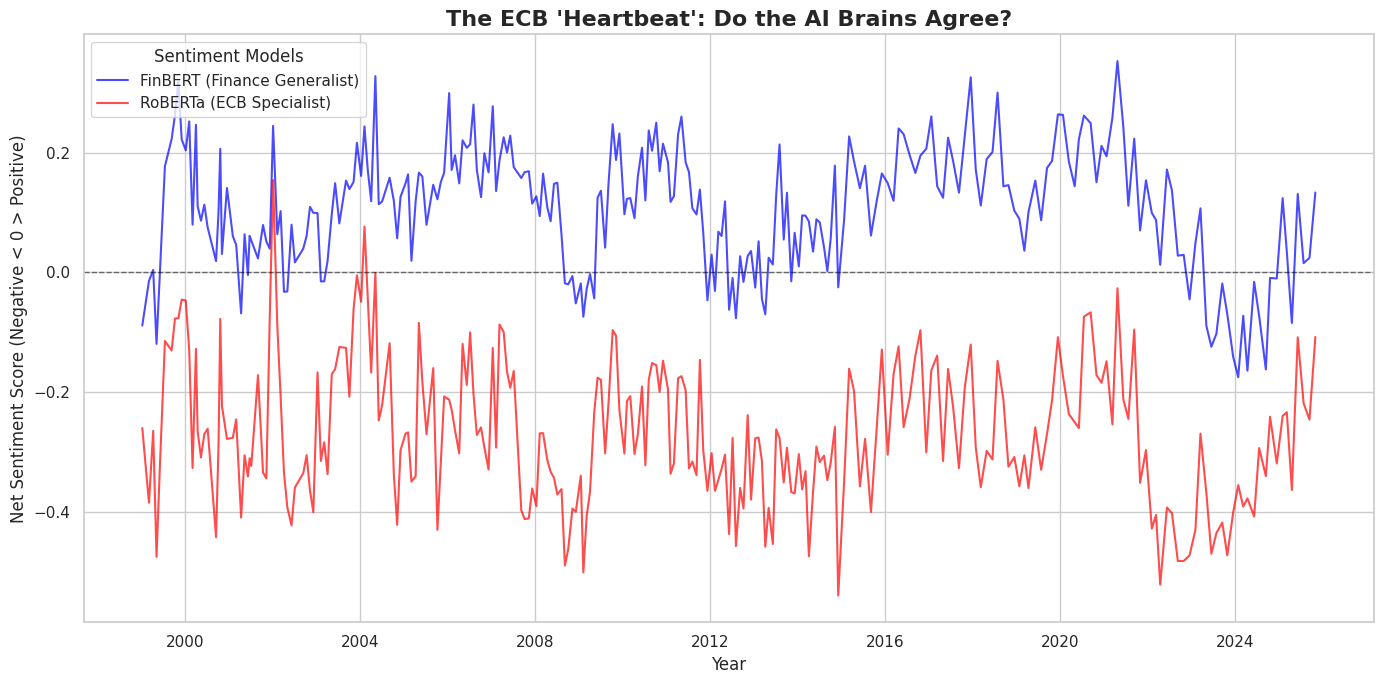

In [11]:
# 1. Setting the style - making it look professional but readable
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 2. Plotting the two "Brains"
# We use the mean (average) sentiment from the Q&A sessions
sns.lineplot(data=data, x=data.index, y='finbert_mean', 
             label='FinBERT (Finance Generalist)', color='blue', alpha=0.7)

sns.lineplot(data=data, x=data.index, y='roberta_mean', 
             label='RoBERTa (ECB Specialist)', color='red', alpha=0.7)

# 3. Customizing the chart to tell a story
plt.title("The ECB 'Heartbeat': Do the AI Brains Agree?", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Net Sentiment Score (Negative < 0 > Positive)", fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5) # The "Neutral" line

# 4. Adding a highlight for the "major shift" detection
# This helps us see where the lines "dive off a cliff" together
plt.legend(title="Sentiment Models", loc='upper left')

plt.tight_layout()
plt.show()

In [26]:
data[["finbert_mean","roberta_mean","roberta_std","finbert_std"]].corr("spearman")

,finbert_mean,roberta_mean,roberta_std,finbert_std
finbert_mean,1.000000,0.701117,0.462268,-0.328247
roberta_mean,0.701117,1.000000,0.517786,-0.165122
roberta_std,0.462268,0.517786,1.000000,0.060443
finbert_std,-0.328247,-0.165122,0.060443,1.000000


In [4]:
return_sentiment_agg_pivot(with_label=False,IS_QA_division=False).columns

Index(['date', 'finbert_max', 'roberta_max', 'finbert_mean', 'roberta_mean',
       'finbert_min', 'roberta_min', 'finbert_std', 'roberta_std',
       'finbert_count', 'roberta_count'],
      dtype='str')

In [5]:
from ..data.sentiment import return_sentiment_agg_pivot
data1 = return_sentiment_agg_pivot(with_label=False,IS_QA_division=False)["finbert_mean"]
data2 = return_sentiment_agg_pivot(with_label=True,IS_QA_division=False)["finbert_MP_mean"]

In [6]:
data1.corr(data2)

np.float64(0.8136997108080056)